# Demand Forecasting with Amazon SageMaker & AutoGluon

This notebook demonstrates an end-to-end demand forecasting pipeline using:
- **AutoGluon-TimeSeries**: State-of-the-art time series forecasting with automatic model selection
- **Amazon SageMaker**: Managed training and inference at scale

## Contents
1. Setup & Configuration
2. Data Preparation
3. Local Training (Development)
4. SageMaker Training (Production)
5. Model Deployment
6. Making Predictions
7. Evaluation & Visualization

## 1. Setup & Configuration

In [ ]:
# Install dependencies (if needed)
# !pip install autogluon.timeseries sagemaker boto3 pandas matplotlib

In [ ]:
!pip install autogluon

In [ ]:
!pip install sagemaker==2.255.0

In [ ]:
!pip install "numpy>=1.24.0,<2.0.0" -q

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Our modules
from data_preparation import DemandDataProcessor
from sagemaker_pipeline import DemandForecastingPipeline, DemandForecastPredictor
from utils import generate_demand_data, evaluate_forecasts, plot_forecast, load_config

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [2]:
# Configuration
CONFIG = {
    # Data settings
    'freq': 'D',  # Daily frequency
    'prediction_length': 30,  # Forecast horizon
    
    # Training settings
    'presets': 'medium_quality',  # fast_training, medium_quality, high_quality, best_quality
    'time_limit': 600,  # 10 minutes for demo
    
    # AWS settings (update these for SageMaker)
    'region': 'us-east-1',
    'instance_type': 'ml.m5.xlarge',
    
    # Evaluation
    'quantiles': [0.1, 0.25, 0.5, 0.75, 0.9]
}

print("Configuration loaded!")

Configuration loaded!


## 2. Data Preparation

In [3]:
# Generate sample demand data
# Replace this with your own data loading code

df = generate_demand_data(n_items=300, n_days=365, seed=42)

print(f"Generated data shape: {df.shape}")
print(f"Items: {df['item_id'].nunique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Generated data shape: (109500, 18)
Items: 300
Date range: 2024-01-01 to 2024-12-30


,item_id,timestamp,target,category,price,is_promotion,is_holiday,holiday_name,is_weekend,is_month_start,is_month_end,day_of_week,day_of_month,day_of_year,week_of_year,month,quarter,year
0,SKU_0000,2024-01-01,341.14,GROCERY,10.32,0,0,None,0,1,0,0,1,1,1,1,1,2024
1,SKU_0000,2024-01-02,382.71,GROCERY,10.14,0,0,None,0,1,0,1,2,2,1,1,1,2024
2,SKU_0000,2024-01-03,385.89,GROCERY,9.77,0,0,None,0,1,0,2,3,3,1,1,1,2024
3,SKU_0000,2024-01-04,290.21,GROCERY,9.71,0,0,None,0,1,0,3,4,4,1,1,1,2024
4,SKU_0000,2024-01-05,246.55,GROCERY,9.14,0,0,None,0,1,0,4,5,5,1,1,1,2024


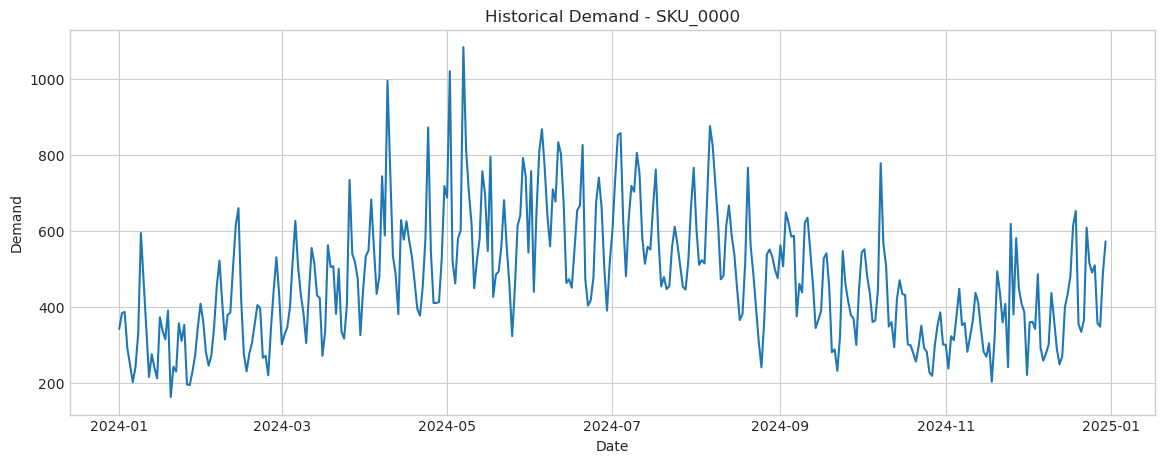

In [4]:
# Visualize sample item
sample_item = df['item_id'].unique()[0]
item_df = df[df['item_id'] == sample_item]

plt.figure(figsize=(14, 5))
plt.plot(pd.to_datetime(item_df['timestamp']), item_df['target'])
plt.title(f'Historical Demand - {sample_item}')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.show()

In [5]:
# Initialize data processor
processor = DemandDataProcessor(
    item_id_column='item_id',
    timestamp_column='timestamp',
    target_column='target',
    freq='D'
)

# Validate data
validation = processor.validate_time_series(df)
print("Data Validation Results:")
for key, value in validation.items():
    print(f"  {key}: {value}")

Data Validation Results:
  total_rows: 109500
  num_items: 300
  date_range: ('2024-01-01', '2024-12-30')
  missing_values: {'holiday_name': 99600}
  negative_targets: 0
  zero_targets: 0
  gaps: []


In [6]:
# Split into train/test
train_df, test_df = processor.train_test_split(
    df, 
    prediction_length=CONFIG['prediction_length']
)

print(f"Training data: {len(train_df)} rows")
print(f"Test data: {len(test_df)} rows")

# Save for later use
train_df.to_csv('../data/train.csv', index=False)
test_df.to_csv('../data/test.csv', index=False)

INFO:data_preparation:Splitting data with prediction_length=30
INFO:data_preparation:Train: 100500 rows, Test: 9000 rows


Training data: 100500 rows
Test data: 9000 rows


## 3. Local Training (Development Mode)

For rapid iteration and development, train locally using AutoGluon.

In [7]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

# Convert to AutoGluon format
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])

train_ts = TimeSeriesDataFrame.from_data_frame(
    train_df,
    id_column='item_id',
    timestamp_column='timestamp'
)

print(f"TimeSeriesDataFrame created with {train_ts.num_items} items")

TimeSeriesDataFrame created with 300 items


In [8]:
# Create and train predictor
predictor = TimeSeriesPredictor(
    path='../models/local_model',
    prediction_length=CONFIG['prediction_length'],
    freq=CONFIG['freq'],
    target='target',
    eval_metric='MASE',
    quantile_levels=CONFIG['quantiles']
)

# Train with fast settings for demo
predictor.fit(
    train_data=train_ts,
    presets='fast_training',  # Use 'medium_quality' or higher for production
    time_limit=300,  # 5 minutes
)

Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '../models/local_model'
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.11.10
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Mon Nov  3 18:38:36 UTC 2025
CPU Count:          2
GPU Count:          0
Memory Avail:       1.49 GB / 3.74 GB (39.9%)
Disk Space Avail:   44.68 GB / 49.94 GB (89.5%)
Setting presets to: fast_training

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'freq': 'D',
 'hyperparameters': 'very_light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 30,
 'quantile_levels': [0.1, 0.25, 0.5, 0.75, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': False,
 'target': 'target',
 'time_limit': 300,
 'verbosity': 2}

Provided train_data has 100500 rows, 300 time series. Median time series length 

In [9]:
# View model leaderboard
leaderboard = predictor.leaderboard(train_ts)
print("Model Leaderboard:")
display(leaderboard)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


Model Leaderboard:


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-0.664821,-0.664821,8.624371,20.675539,1.030148,6
1,Theta,-0.717590,-0.717590,7.399022,19.441381,0.134375,5
2,SeasonalNaive,-0.825070,-0.825070,0.407244,0.413475,0.146916,2
3,DirectTabular,-0.914871,-0.914871,0.416730,0.404877,5.288676,4
4,Naive,-0.964940,-0.964940,0.391774,0.415805,0.187907,1
5,RecursiveTabular,-1.048852,-1.048852,1.102656,1.834693,12.217980,3


In [10]:
# Generate predictions
predictions = predictor.predict(train_ts)
predictions = predictions.reset_index()

print(f"Generated {len(predictions)} predictions")
print(f"Columns: {list(predictions.columns)}")
predictions.head()

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


Generated 9000 predictions
Columns: ['item_id', 'timestamp', 'mean', '0.1', '0.25', '0.5', '0.75', '0.9']


,item_id,timestamp,mean,0.1,0.25,0.5,0.75,0.9
0,SKU_0000,2024-12-01,349.711100,246.273917,291.906430,349.711100,407.264322,459.177242
1,SKU_0000,2024-12-02,470.928112,342.424432,405.670404,470.928112,533.080795,598.590591
2,SKU_0000,2024-12-03,516.172780,342.087895,426.445583,516.172780,598.939506,679.464667
3,SKU_0000,2024-12-04,544.270928,382.560422,455.568861,544.270928,631.614177,709.197818
4,SKU_0000,2024-12-05,489.640312,322.520318,404.469347,489.640312,574.961519,660.612196


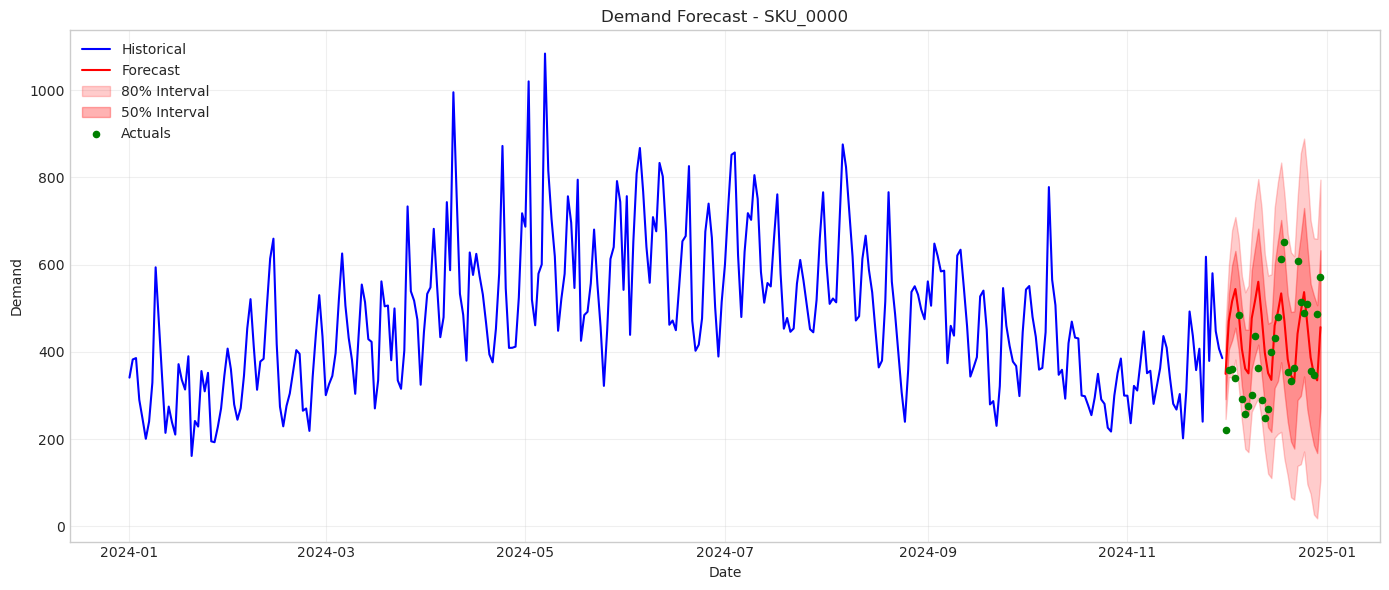

In [11]:
# Visualize forecast for sample item
fig = plot_forecast(
    historical=train_df,
    predictions=predictions,
    item_id=sample_item,
    actuals=test_df,
    title=f'Demand Forecast - {sample_item}'
)
plt.show()

## 4. SageMaker Training (Production Mode)

For production workloads, use SageMaker for managed training.

In [23]:
import os

# Get absolute path to src directory
src_path = os.path.abspath("../src")
print(f"Source dir: {src_path}")

Source dir: /home/sagemaker-user/DemoNotebooks/MachineLearning/src


In [24]:
# Initialize SageMaker pipeline

pipeline = DemandForecastingPipeline(
    region=CONFIG['region'],
    prefix='demand-forecasting',
    source_dir=src_path
)
pipeline.source_dir = "../src"

# Train on SageMaker
training_job = pipeline.train(
    train_data='../data/train.csv',
    hyperparameters={
        'prediction_length': CONFIG['prediction_length'],
        'freq': CONFIG['freq'],
        'presets': CONFIG['presets'],
        'time_limit': CONFIG['time_limit'],
    },
    instance_type=CONFIG['instance_type'],
    wait=True
)

print(f"Training completed: {training_job}")
print(f"Model artifacts: {pipeline.model_data}")

INFO:__main__:Initialized pipeline in region us-east-1
INFO:__main__:Using bucket: sagemaker-us-east-1-851232299337, prefix: demand-forecasting
INFO:__main__:AutoGluon version: 1.1.1
INFO:__main__:Source directory: /home/sagemaker-user/DemoNotebooks/MachineLearning/src
INFO:__main__:Uploaded train data to s3://sagemaker-us-east-1-851232299337/demand-forecasting/data/20251217-194337/train.csv
INFO:sagemaker.image_uris:Defaulting to only available Python version: py311
INFO:__main__:Using training image: 763104351884.dkr.ecr.us-east-1.amazonaws.com/autogluon-training:1.1.1-cpu-py311
INFO:__main__:Starting training job: demand-forecast-20251217-194338
INFO:__main__:Instance type: ml.m5.xlarge
INFO:__main__:Source directory: ../src
INFO:__main__:Hyperparameters: {'prediction-length': '30', 'freq': 'D', 'presets': 'medium_quality', 'time-limit': '600', 'eval-metric': 'MASE', 'quantile-levels': '0.1,0.25,0.5,0.75,0.9', 'enable-ensemble': 'true'}
INFO:sagemaker:Creating training-job with name

2025-12-17 19:43:40 Starting - Starting the training job...
2025-12-17 19:43:55 Starting - Preparing the instances for training...
2025-12-17 19:44:37 Downloading - Downloading the training image.........
2025-12-17 19:46:09 Training - Training image download completed. Training in progress..bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
2025-12-17 19:46:15,443 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2025-12-17 19:46:15,444 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2025-12-17 19:46:15,444 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2025-12-17 19:46:15,453 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2025-12-17 19:46:15,455 sagemaker_pytorch_container.training INFO     Invoking user training script.
2025-12-17 19:46:16,992 sagemaker-training-too

INFO:__main__:Training completed. Model artifacts: s3://sagemaker-us-east-1-851232299337/demand-forecasting/models/demand-forecast-20251217-194338/output/model.tar.gz


Training seconds: 496
Billable seconds: 496
Training completed: demand-forecast-20251217-194338
Model artifacts: s3://sagemaker-us-east-1-851232299337/demand-forecasting/models/demand-forecast-20251217-194338/output/model.tar.gz


## 5. Model Deployment

In [25]:
# Deploy to real-time endpoint (SageMaker)

predictor_endpoint = pipeline.deploy(
    instance_type='ml.m5.large',
    instance_count=1,
    wait=True
)

print(f"Endpoint deployed: {pipeline.endpoint_name}")

INFO:sagemaker.image_uris:Defaulting to only available Python version: py311
INFO:__main__:Using inference image: 763104351884.dkr.ecr.us-east-1.amazonaws.com/autogluon-inference:1.1.1-cpu-py311
INFO:sagemaker:Repacking model artifact (s3://sagemaker-us-east-1-851232299337/demand-forecasting/models/demand-forecast-20251217-194338/output/model.tar.gz), script artifact (../src), and dependencies ([]) into single tar.gz file located at s3://sagemaker-us-east-1-851232299337/demand-forecast-model-20251217-195313/model.tar.gz. This may take some time depending on model size...
INFO:sagemaker:Creating model with name: demand-forecast-model-20251217-195313
INFO:__main__:Created model: demand-forecast-model-20251217-195313
INFO:__main__:Deploying model demand-forecast-model-20251217-195313 to endpoint demand-forecast-endpoint-20251217-195326
INFO:__main__:Instance type: ml.m5.large, Count: 1
INFO:__main__:Waiting for endpoint to be ready...
INFO:__main__:Endpoint demand-forecast-endpoint-202512

Endpoint deployed: demand-forecast-endpoint-20251217-195326


## 6. Making Predictions

In [26]:
# Predict using local model
# For endpoint predictions, use: predictor_endpoint.predict(data)

# Get predictions for all items
all_predictions = predictor.predict(train_ts)
all_predictions = all_predictions.reset_index()

print(f"Total predictions: {len(all_predictions)}")
print(f"Unique items: {all_predictions['item_id'].nunique()}")

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


Total predictions: 9000
Unique items: 300


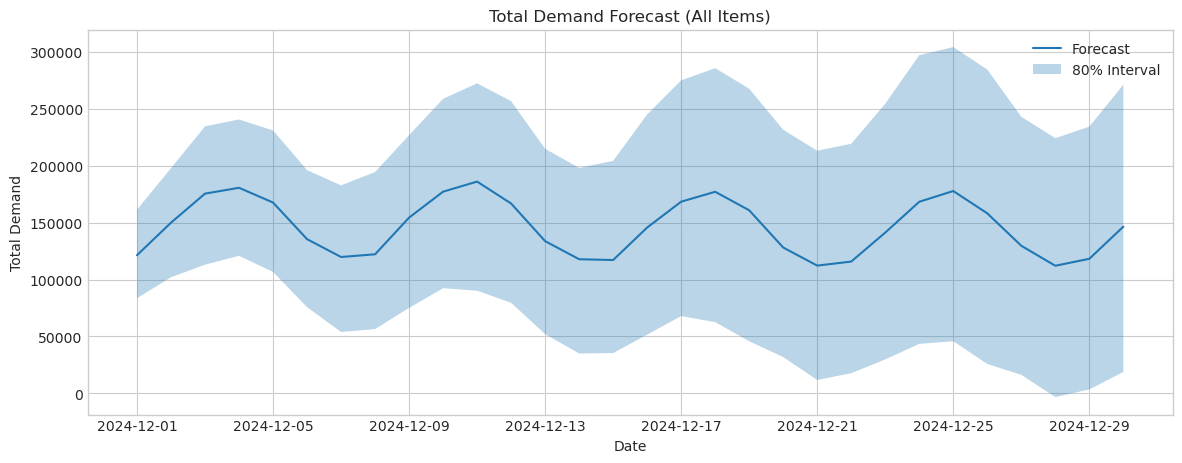

In [27]:
# Aggregate predictions by date (total demand)
daily_forecast = all_predictions.groupby('timestamp').agg({
    'mean': 'sum',
    '0.1': 'sum',
    '0.9': 'sum'
}).reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_forecast['timestamp'], daily_forecast['mean'], label='Forecast')
plt.fill_between(
    daily_forecast['timestamp'],
    daily_forecast['0.1'],
    daily_forecast['0.9'],
    alpha=0.3,
    label='80% Interval'
)
plt.title('Total Demand Forecast (All Items)')
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.legend()
plt.show()

## 7. Evaluation

In [ ]:
# Evaluate predictions against test data
if len(test_df) > 0:
    test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
    
    metrics = evaluate_forecasts(
        test_df,
        all_predictions,
        target_column='target',
        item_id_column='item_id'
    )
    
    print("Evaluation Metrics:")
    print("=" * 40)
    for metric, value in metrics.items():
        print(f"{metric:20s}: {value:.4f}")

In [ ]:
# Visualize multiple items
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, item_id in enumerate(train_df['item_id'].unique()[:4]):
    ax = axes[idx // 2, idx % 2]
    
    # Historical
    hist = train_df[train_df['item_id'] == item_id]
    ax.plot(pd.to_datetime(hist['timestamp']), hist['target'], label='Historical', color='blue')
    
    # Forecast
    pred = all_predictions[all_predictions['item_id'] == item_id]
    ax.plot(pred['timestamp'], pred['mean'], label='Forecast', color='red')
    ax.fill_between(pred['timestamp'], pred['0.1'], pred['0.9'], alpha=0.2, color='red')
    
    # Actuals if available
    if len(test_df) > 0:
        act = test_df[test_df['item_id'] == item_id]
        ax.scatter(pd.to_datetime(act['timestamp']), act['target'], color='green', s=20, label='Actual', zorder=5)
    
    ax.set_title(item_id)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cleanup

Remember to clean up SageMaker resources when done!

In [ ]:
# Cleanup SageMaker resources (uncomment when needed)

# pipeline.cleanup(
#     delete_endpoint=True,
#     delete_model=True
# )

## Next Steps

1. **Use your own data**: Replace the sample data with your actual demand data
2. **Add features**: Include promotions, holidays, prices as covariates
3. **Tune models**: Increase `time_limit` and use `high_quality` preset
4. **Scale**: Use SageMaker for larger datasets and production deployment
5. **Automate**: Set up SageMaker Pipelines for automated retraining